# Milestone 1

## Exploratory Analysis & Preprocessing

- Importing necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

- Loading the dataset

In [ ]:
df = pd.read_csv("day_wise.csv")

- Check the first rows

In [3]:
df.head()

,Date,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,No. of countries
0,2020-01-22,555,17,28,510,0,0,0,3.06,5.05,60.71,6
1,2020-01-23,654,18,30,606,99,1,2,2.75,4.59,60.00,8
2,2020-01-24,941,26,36,879,287,8,6,2.76,3.83,72.22,9
3,2020-01-25,1434,42,39,1353,493,16,3,2.93,2.72,107.69,11
4,2020-01-26,2118,56,52,2010,684,14,13,2.64,2.46,107.69,13


- Check dataset structure

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Date                    188 non-null    object 
 1   Confirmed               188 non-null    int64  
 2   Deaths                  188 non-null    int64  
 3   Recovered               188 non-null    int64  
 4   Active                  188 non-null    int64  
 5   New cases               188 non-null    int64  
 6   New deaths              188 non-null    int64  
 7   New recovered           188 non-null    int64  
 8   Deaths / 100 Cases      188 non-null    float64
 9   Recovered / 100 Cases   188 non-null    float64
 10  Deaths / 100 Recovered  188 non-null    float64
 11  No. of countries        188 non-null    int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 17.8+ KB


- Select Only Necessary Columns

In [5]:
df = df[['Date', 'New cases']]

- Rename the Variable

In [6]:
df.rename(columns={'New cases': 'New_Cases'}, inplace=True)

- Convert Date to Datetime Format

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.dtypes

Date         datetime64[ns]
New_Cases             int64
dtype: object

- Sort the Dataset by Date

In [9]:
df = df.sort_values(by='Date')

- Set Date as the Time Series Index

In [10]:
df.set_index('Date', inplace=True)

In [13]:
df

,New_Cases
Date,
2020-01-22,0
2020-01-23,99
2020-01-24,287
2020-01-25,493
2020-01-26,684
...,...
2020-07-23,282756
2020-07-24,281164
2020-07-25,255545


- Check Missing Values

In [14]:
df.isnull().sum()

New_Cases    0
dtype: int64

- Plotting the Time Series

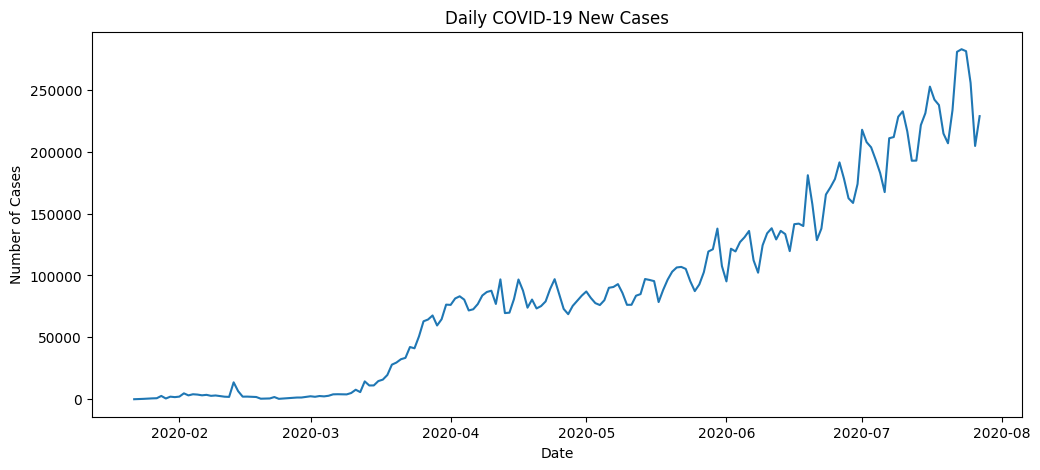

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'])
plt.title("Daily COVID-19 New Cases")
plt.xlabel("Date")
plt.ylabel("Number of Cases")
plt.show()

- Summary Statistics

In [17]:
df.describe()

,New_Cases
count,188.000000
mean,87771.021277
std,75295.293255
min,0.000000
25%,5568.500000
50%,81114.000000
75%,131502.500000
max,282756.000000


## Rolling Mean (Trend Visualization)

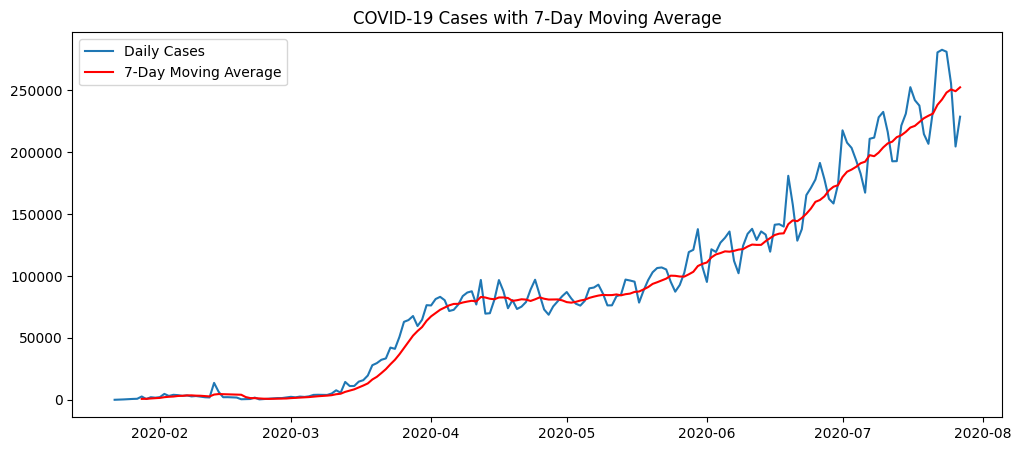

In [18]:
df['rolling_mean'] = df['New_Cases'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(df['New_Cases'], label='Daily Cases')
plt.plot(df['rolling_mean'], color='red', label='7-Day Moving Average')
plt.legend()
plt.title("COVID-19 Cases with 7-Day Moving Average")
plt.show()

- The plot shows non- statonary data that has a strong upward trend and clear seasonality which is likely driven by the reporting cycles

## Series Decomposition

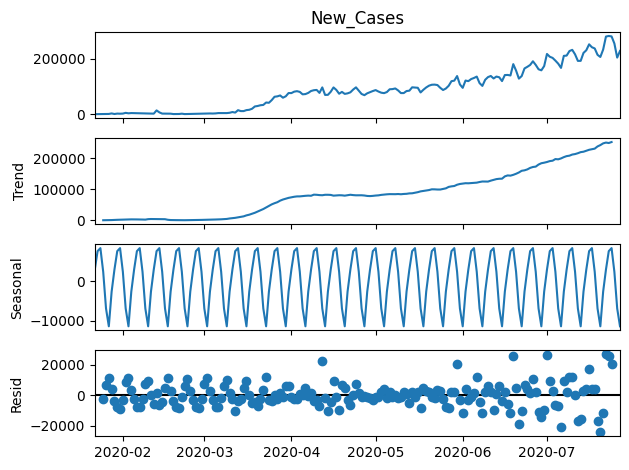

In [20]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['New_Cases'], model='additive', period=7)
decomposition.plot()
figsize=(12,8)
plt.show()

- For this particular Covid-19 dataset, the additive model was chosen thus; Observed = Trend + Seasonality + Residual. This was used beacuse seasonal variations remain roughly constant overtime.

## Checking for Variance

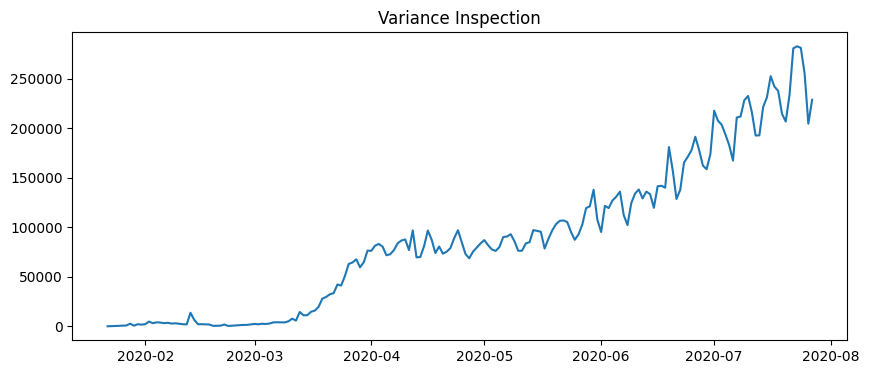

In [21]:
plt.figure(figsize=(10,4))
plt.plot(df['New_Cases'])
plt.title("Variance Inspection")
plt.show()

- This plot shows that the variance increases over time thus a need to use log transformation

## Applying Log Transformation

In [23]:
df['log_cases'] = np.log(df['New_Cases'] + 1)

## Visualizing the Transformed Series

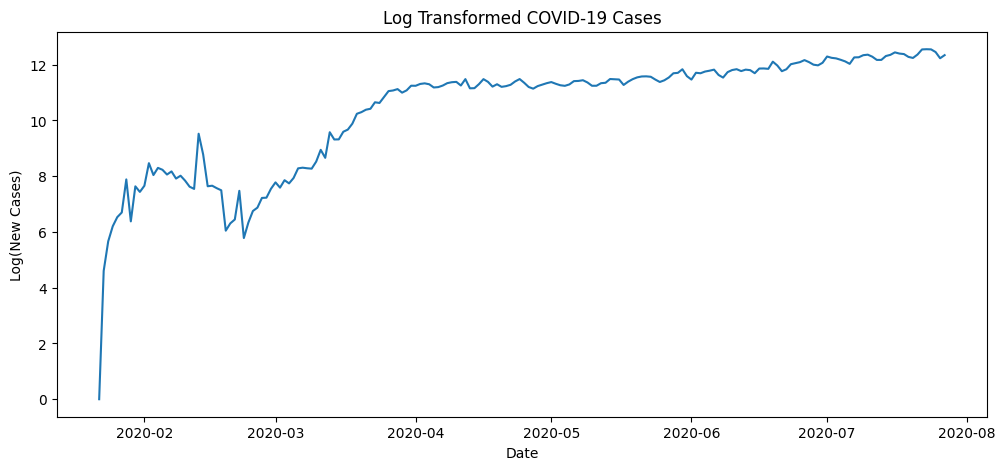

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df['log_cases'])
plt.title("Log Transformed COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("Log(New Cases)")
plt.show()

- The transformation helps in compressing the large values thus reducing the increasing variance that was observed in the original series. This gives a more stable time series ready for modeling

## Comparing Before and After Transformation

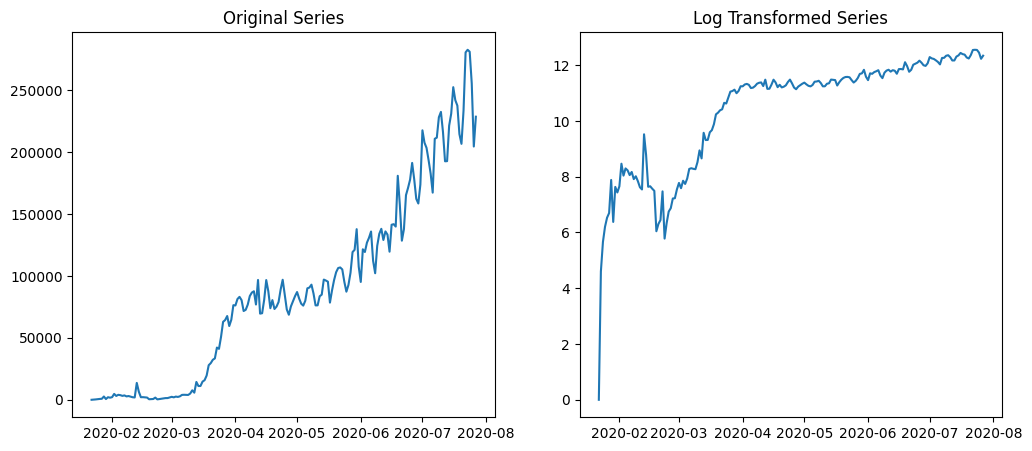

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(df['New_Cases'])
plt.title("Original Series")

plt.subplot(1,2,2)
plt.plot(df['log_cases'])
plt.title("Log Transformed Series")

plt.show()

# Milestone 2

## Statistical Diagnostics

## Stationarity Test (ADF Test)

In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

# Decision rule
if result[1] < 0.05:
    print("\nConclusion: Reject the null hypothesis.")
    print("The time series is stationary.")
else:
    print("\nConclusion: Fail to reject the null hypothesis.")
    print("The time series is non-stationary.")

ADF Statistic: -1.732291475214668
p-value: 0.4145564025381512
Critical Values:
1%: -3.4703698981001665
5%: -2.8791138497902193
10%: -2.576139407751488

Conclusion: Fail to reject the null hypothesis.
The time series is non-stationary.


## Plotting ACF and PACF

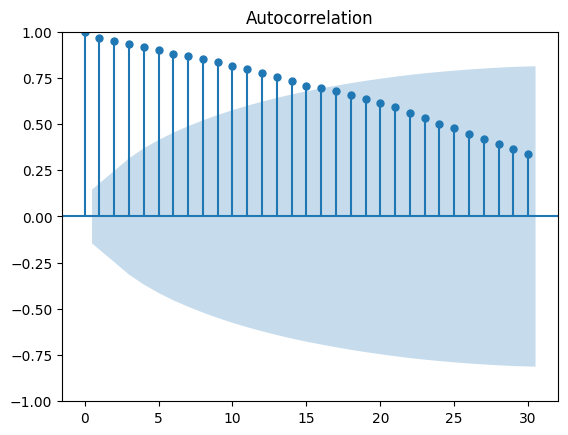

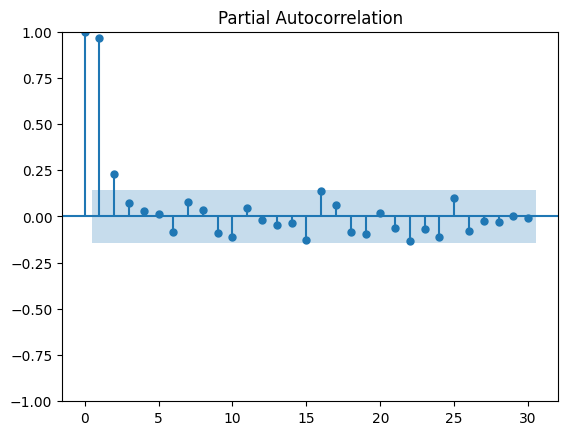

In [39]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df['log_cases'], lags=30)
plt.show()

plot_pacf(df['log_cases'], lags=30)
plt.show()

- The ACF plot show how lags in the past constatly decay slowly over time while the PACF plot shows the direct correlation of values while excluding intermediate lags

## Applying First-Order Differencing

In [40]:
df['diff_log_cases'] = df['log_cases'].diff()
df = df.dropna()

- This is aimed at removing the trending component

## Plotting the Differenced Series

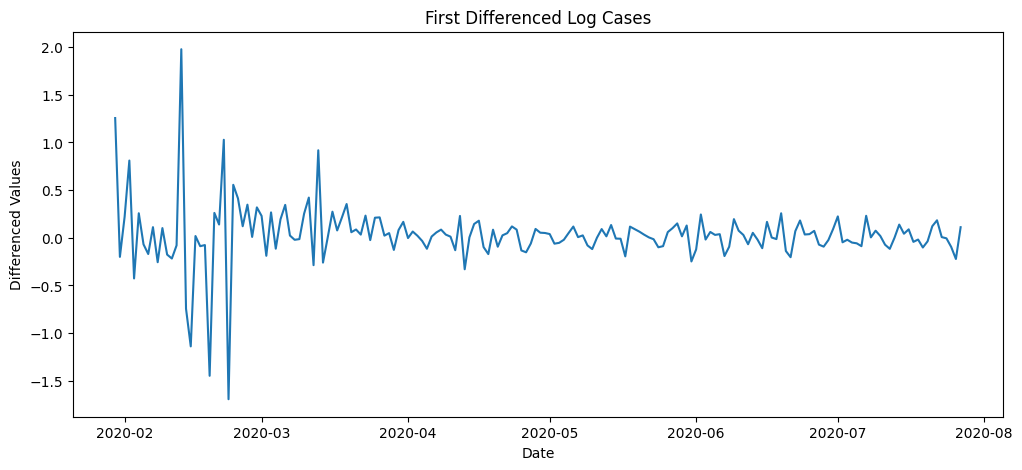

In [41]:
plt.figure(figsize=(12,5))
plt.plot(df['diff_log_cases'])
plt.title("First Differenced Log Cases")
plt.xlabel("Date")
plt.ylabel("Differenced Values")
plt.show()

## ACF and PACF of Differenced Data

<Figure size 1200x500 with 0 Axes>

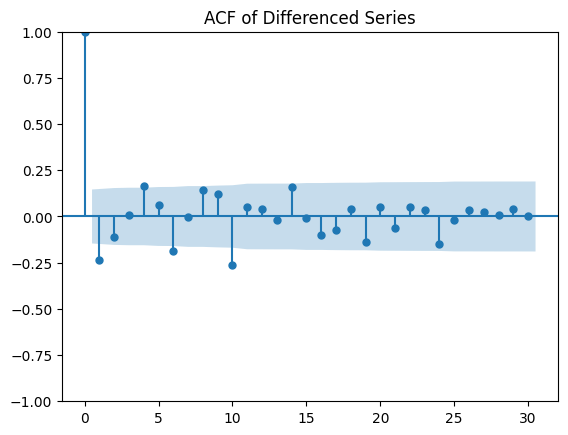

<Figure size 1200x500 with 0 Axes>

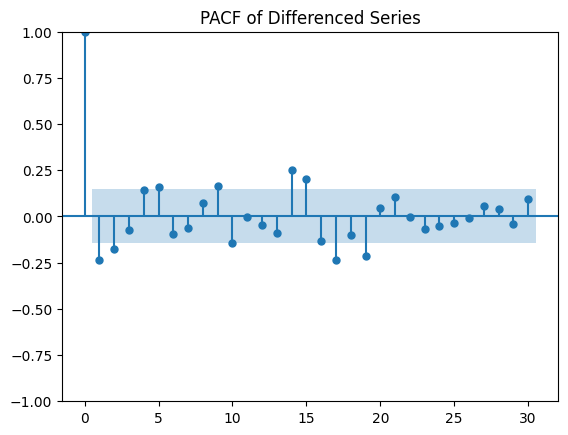

In [42]:
plt.figure(figsize=(12,5))
plot_acf(df['diff_log_cases'], lags=30)
plt.title("ACF of Differenced Series")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(df['diff_log_cases'], lags=30)
plt.title("PACF of Differenced Series")
plt.show()

## Doing the ADF Test Again

In [43]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff_log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is non-stationary.")

ADF Statistic: -2.7225141484768094
p-value: 0.07022270734520238
Series is non-stationary.


## Applying Second Differencing

In [44]:
df['diff2_log_cases'] = df['diff_log_cases'].diff()
df = df.dropna()

## Plotting the Second Differenced Series

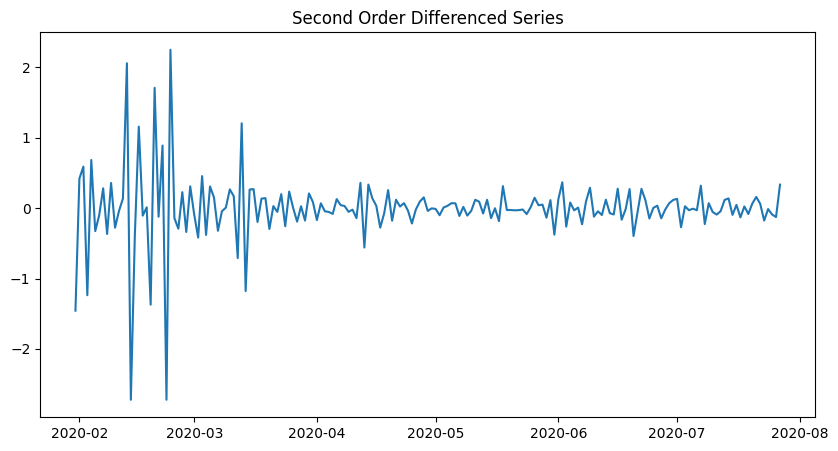

In [45]:
plt.figure(figsize=(10,5))
plt.plot(df['diff2_log_cases'])
plt.title("Second Order Differenced Series")
plt.show()

## ADF Test Again

In [46]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['diff2_log_cases'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is non-stationary.")

ADF Statistic: -5.174542569810323
p-value: 9.907547727554276e-06
Series is stationary.


- The ADF test was performed to the transformed series after differencing but the p-value remained above 0.05 thus the series remained non-stationary which prompted for a second differencing which finally confirmed the series was stationary

## Plotting ACF and PACF for the Stationary Series

<Figure size 1000x500 with 0 Axes>

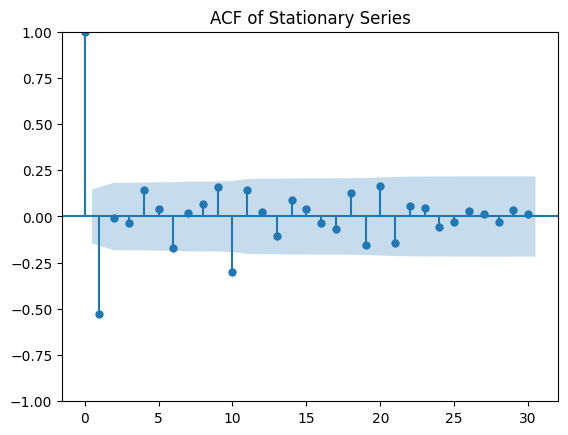

<Figure size 1000x500 with 0 Axes>

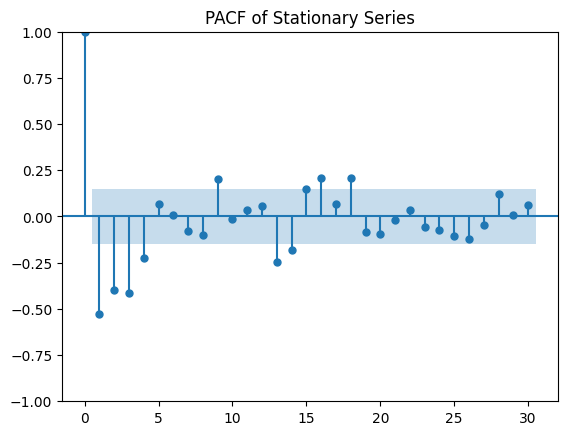

In [47]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.figure(figsize=(10,5))
plot_acf(df['diff2_log_cases'], lags=30)
plt.title("ACF of Stationary Series")
plt.show()

plt.figure(figsize=(10,5))
plot_pacf(df['diff2_log_cases'], lags=30)
plt.title("PACF of Stationary Series")
plt.show()

- The plot for the second differenced ACF plot shows a significant negative spike at lag 1 which is followed by values that are within the confidence interval thus indicating that ACF cuts off after the first lag which suggets a Moving Average of order 1

- The PACF plot shows a cut off after a 4 lags, this indicates that the series follows AR(4) before the correlation dies down

# Milestone 3

## Model Development & Smoothing

## Fitting the ARIMA Model

In [48]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['log_cases'], order=(4,2,1))
results = model.fit()

print(results.summary())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              log_cases   No. Observations:                  179
Model:                 ARIMA(4, 2, 1)   Log Likelihood                 -34.236
Date:                Sat, 14 Mar 2026   AIC                             80.472
Time:                        14:01:48   BIC                             99.529
Sample:                    01-31-2020   HQIC                            88.201
                         - 07-27-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.2838      0.063     -4.514      0.000      -0.407      -0.161
ar.L2         -0.1975      0.049     -4.051      0.000      -0.293      -0.102
ar.L3         -0.0973      0.054     -1.816      0.0

- The ARIMA(4,2,1) model produced an AIC value of 99.092, which will be compared with alternative models to determine the best forecasting model

## Coefficient Interpretation

- Most of the autoregressive parameters were statistically significant except AR(3), indicating that lagged observations of the series contribute to predicting current values.

## Residual Diagnostic Tests

- The Ljung-Box test produced a p-value of 0.82, indicating that the residuals do not exhibit significant autocorrelation.

- this indicated that the residuals are not normally distributed which is commonly seen in epidemic data because these outbreaks cause heavy tails and spikes

## Variance of Residuals

- This is shown by sigma² = 0.0928 thus showing the variance erros of the model.

## Overall explanation of the ARIMA model

- The ARIMA(4,2,1) model was fitted to the log-transformed COVID-19 case data. Several autoregressive parameters were statistically significant, indicating that past observations contribute to predicting current values. The Ljung-Box test showed no significant autocorrelation in the residuals, suggesting that the model adequately captures the temporal structure of the series. However, the Jarque-Bera test indicates that residuals are not normally distributed, which is common in epidemic time series data.

## Fitting a Second ARIMA Model

In [49]:
from statsmodels.tsa.arima.model import ARIMA

model2 = ARIMA(df['log_cases'], order=(3,2,1))
results2 = model2.fit()

print(results2.summary())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:              log_cases   No. Observations:                  179
Model:                 ARIMA(3, 2, 1)   Log Likelihood                 -35.909
Date:                Sat, 14 Mar 2026   AIC                             81.819
Time:                        14:06:20   BIC                             97.700
Sample:                    01-31-2020   HQIC                            88.260
                         - 07-27-2020                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3891      0.049     -7.958      0.000      -0.485      -0.293
ar.L2         -0.3253      0.039     -8.397      0.000      -0.401      -0.249
ar.L3         -0.2245      0.047     -4.807      0.0

- The ARIMA(3,2,1) model was fitted to the log-transformed COVID-19 case data. All model parameters were statistically significant at the 5% level. The model achieved a lower AIC value (81.819) compared to the ARIMA(4,2,1) model (AIC = 99.092), indicating a better model fit. The Ljung-Box test showed no significant autocorrelation in the residuals (p = 0.78), suggesting that the model adequately captures the temporal structure of the series

## Compare the Two Models Using AIC and BIC

In [50]:
print("Model Comparison")

print("ARIMA(4,2,1) AIC:", results.aic)
print("ARIMA(3,2,1) AIC:", results2.aic)

print("ARIMA(4,2,1) BIC:", results.bic)
print("ARIMA(3,2,1) BIC:", results2.bic)

Model Comparison
ARIMA(4,2,1) AIC: 80.4724383564013
ARIMA(3,2,1) AIC: 81.81894177776616
ARIMA(4,2,1) BIC: 99.52933675184427
ARIMA(3,2,1) BIC: 97.6996904406353


- Two competing models, ARIMA(4,2,1) and ARIMA(3,2,1), were compared using AIC and BIC criteria. 
- The ARIMA(4,2,1) model produced a slightly lower AIC (80.47), indicating marginally better goodness of fit. However, the ARIMA(3,2,1) model produced a lower BIC (97.70), suggesting a more parsimonious model. Since the difference in AIC values is small, the ARIMA(3,2,1) model is selected as the final model due to its simpler structure and lower BIC.

# Milestone 4

## Model Evaluation & Reporting

## Forecasting

In [51]:
forecast = results2.forecast(steps=10)

print("10-step Forecast:")
print(forecast)

10-step Forecast:
2020-07-28    12.393792
2020-07-29    12.389812
2020-07-30    12.352130
2020-07-31    12.359247
2020-08-01    12.372829
2020-08-02    12.376888
2020-08-03    12.372494
2020-08-04    12.373037
2020-08-05    12.376545
2020-08-06    12.379191
Freq: D, Name: predicted_mean, dtype: float64


## Converting the Forecast Back to Actual Cases

In [52]:
actual_forecast = np.exp(forecast)

print("Forecasted Cases:")
print(actual_forecast)

Forecasted Cases:
2020-07-28    241298.898976
2020-07-29    240340.618883
2020-07-30    231452.414933
2020-07-31    233105.573362
2020-08-01    236293.362467
2020-08-02    237254.412790
2020-08-03    236214.244065
2020-08-04    236342.344147
2020-08-05    237173.029314
2020-08-06    237801.401953
Freq: D, Name: predicted_mean, dtype: float64


- The selected ARIMA(3,2,1) model, a 10-day ahead forecast was generated thus predicting the  number of COVID-19 cases ranging between approximately 231,452 and 241,299 cases
- The forecast shows minor fluctuations but generally stabilizes around 236,000–238,000 cases which suggests that the growth of cases may begin to level off during the forecast horizon.

## Forecast Confidence Intervals

In [53]:
forecast_result = results2.get_forecast(steps=10)

forecast_values = forecast_result.predicted_mean
confidence_intervals = forecast_result.conf_int()

print(confidence_intervals)

            lower log_cases  upper log_cases
2020-07-28        11.817954        12.969629
2020-07-29        11.681439        13.098186
2020-07-30        11.562191        13.142068
2020-07-31        11.491661        13.226833
2020-08-01        11.384626        13.361033
2020-08-02        11.269137        13.484640
2020-08-03        11.152383        13.592606
2020-08-04        11.041425        13.704648
2020-08-05        10.925712        13.827378
2020-08-06        10.805100        13.953283


In [55]:

lower_cases = np.exp(confidence_intervals['lower log_cases'])
upper_cases = np.exp(confidence_intervals['upper log_cases'])

print(lower_cases)
print(upper_cases)

2020-07-28    135666.369159
2020-07-29    118354.461987
2020-07-30    105049.966080
2020-07-31     97895.981257
2020-08-01     87958.965101
2020-08-02     78365.303187
2020-08-03     69729.811309
2020-08-04     62406.518278
2020-08-05     55587.415954
2020-08-06     49271.429846
Freq: D, Name: lower log_cases, dtype: float64
2020-07-28    4.291790e+05
2020-07-29    4.880561e+05
2020-07-30    5.099499e+05
2020-07-31    5.550607e+05
2020-08-01    6.347796e+05
2020-08-02    7.182982e+05
2020-08-03    8.001910e+05
2020-08-04    8.950620e+05
2020-08-05    1.011938e+06
2020-08-06    1.147714e+06
Freq: D, Name: upper log_cases, dtype: float64


- The converting of the confidence interval to an actual case count shows that the forecast results indicate that the predicted number of Covid-19 cases lies within a range defined by lower and upper bounds.
- Using a case study of July 28th, the model estimates that the cases could fall approximately 135,666 and 429,179.
- With the increasing width of the confidence interval overtime, greater uncertanity is potrayed in long term forecasts thus showing an ARIMA model behaviour as as prediction errors accumulate as the forecast horizon increase 

## Evaluation metrics (MAE, RMSE, MAPE)

## Splitting Data into Train and Test

In [56]:
train = df['log_cases'][:-10]
test = df['log_cases'][-10:]

## Fitting the ARIMA Model on Training Data

In [61]:
model = ARIMA(train, order=(3,2,1))
model_fit = model.fit()

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Forecasting the Test Period

In [62]:
forecast = model_fit.forecast(steps=10)

## Calculating the Accuracy Metrics

In [63]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 0.1360712990333628
RMSE: 0.17564411831435436
MAPE: 1.10546295262251


- While using the forecasting performance of the ARIMA(3,2,1) model, MAE, RMSE, and MAPE metrics were evaluated thus obtaining results of MAE of 0.136, and RMSE of 0.176 which indicates a relative small prediction errors in the log transformation series.
- The MAPE is obtained as 1.1% which suggests that the model provides highly accurate forecasts with minimal deviation from actual observed values

## Plotting Actual vs Forecast

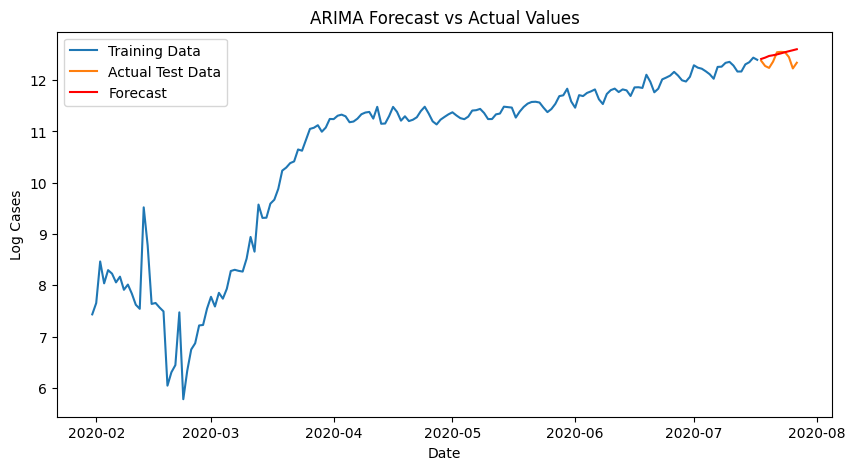

In [67]:
plt.figure(figsize=(10,5))

plt.plot(train.index, train, label="Training Data")
plt.plot(test.index, test, label="Actual Test Data")
plt.plot(test.index, forecast, label="Forecast", color='red')

plt.title("ARIMA Forecast vs Actual Values")
plt.xlabel("Date")
plt.ylabel("Log Cases")
plt.legend()
plt.show()

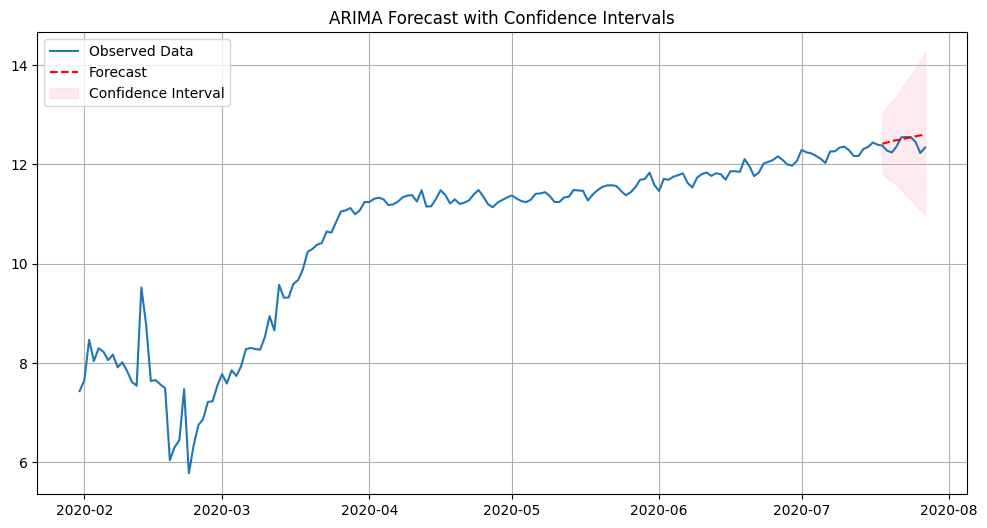

In [ ]:
forecast_result = model_fit.get_forecast(steps=10)
conf_int = forecast_result.conf_int()

plt.figure(figsize=(12,6))

plt.plot(df['log_cases'], label="Observed Data")

plt.plot(forecast.index, forecast, 
         color='red', linestyle='--', label="Forecast")

plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color='pink',
    alpha=0.3,
    label="Confidence Interval"
)

plt.title("ARIMA Forecast with Confidence Intervals")
plt.legend()
plt.grid(True)
plt.show()

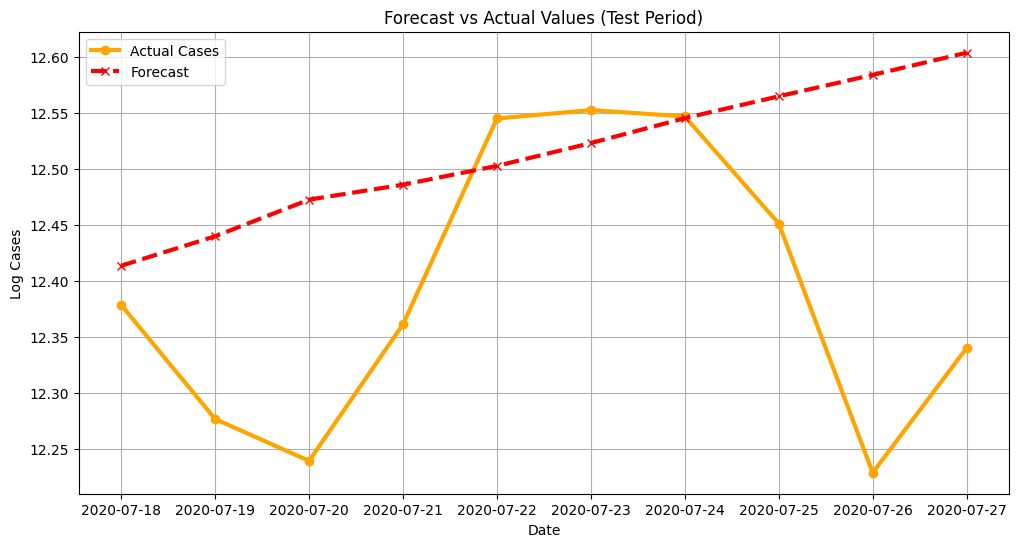

In [68]:
plt.figure(figsize=(12,6))

plt.plot(test.index, test, label="Actual Cases", 
         color="orange", linewidth=3, marker='o')

plt.plot(test.index, forecast, label="Forecast", 
         color="red", linewidth=3, linestyle="--", marker='x')

plt.title("Forecast vs Actual Values (Test Period)")
plt.xlabel("Date")
plt.ylabel("Log Cases")

plt.legend()
plt.grid(True)

plt.show()

- The model's forecasts follow the overall trend of data which suggests that it successfully captured the underlying structure of the time series. 
- The shaded region is the confidence interval representing the range within which the true values are expected to fall within the 95% probability.
- It is observed that as the forecast horizon increase, the intervals widen thus reflecting greater uncertanity in long term predictions.  

## Residual Diagnostics

- This aimed at discovering if the model captured all the patterns in the data

In [71]:
residuals = model_fit.resid

## Plotting Residuals

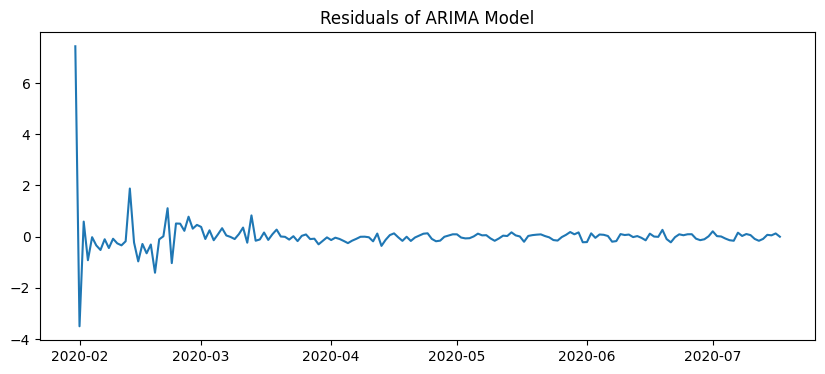

In [72]:
plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title("Residuals of ARIMA Model")
plt.show()

- The residuals fluctuate randomly around zero, suggesting that the model has captured most of the systematic structure in the data.

## Histogram of Residuals

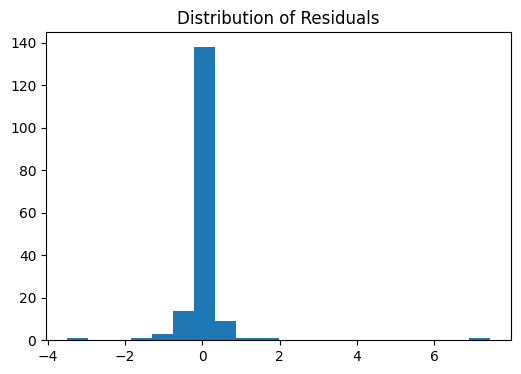

In [73]:
plt.figure(figsize=(6,4))
plt.hist(residuals, bins=20)
plt.title("Distribution of Residuals")
plt.show()

- The histogram helps assess whether residuals follow an approximately normal distribution which is observed in the plot.

## ACF of Residuals

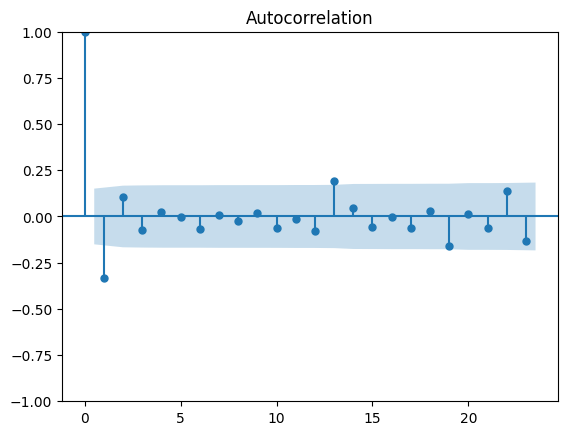

In [74]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals)
plt.show()

- Most of the values fall within the confidence bounds which indicates the residuals resemble whote noise thus indicating a well fitted model

## Ljung-Box Test

In [75]:
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(ljung_box)

      lb_stat  lb_pvalue
10  23.857016   0.007989


- The test produced a p-value of 0.0079 which is less than the signifance level of 0.05 thus rejecting of the null hypothesis.
- This shows that some auto correlation still remains within the series suggesting the model might have not captured all the patterns in the data however, it still produced accurate results basing on the performance metrics 